# Carteras con siete activos reales

En este notebook, vamos a construir carteras de inversión con siete activos reales. Aprenderemos a calcular la rentabilidad y volatilidad usando matrices y a generar múltiples carteras con pesos aleatorios para los activos. 

In [146]:
import numpy as np

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

## 1. Descarga de precios

Lectura de los archivos CSV

In [147]:
# Lista de nombres de activos.
activos = [
    "ES0160994002",
    "IE00B42W3S00",
    "IE00BZ4D7648",
    "IE000U9ODG19",
    "LU0261948904",
    "LU0996179007",
    "LU1213836080",
]
# Carpeta donde se encuentran los ficheros.
root_path = "https://raw.githubusercontent.com/alfonso-santos/microcredencial-carteras-python/refs/heads/Feb-2025/Tema_2_Carteras_Intro/data/"
# Creamos una lista para almacenar todos los DF.
df_list = []
# Leemos los ficheros y creamos los DF.
for file_name in activos:
    df = pd.read_csv(root_path + file_name + ".csv", delimiter=";")
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date")
    df_list.append(df)
# Combinamos todos los DF en uno solo.
data = pd.concat(df_list, axis=1)
# Renombramos las columnas.
data.columns = activos

data

C:\Users\pventura\AppData\Local\Temp\ipykernel_31820\1172564909.py:18: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])
C:\Users\pventura\AppData\Local\Temp\ipykernel_31820\1172564909.py:18: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])
C:\Users\pventura\AppData\Local\Temp\ipykernel_31820\1172564909.py:18: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"])
C:\Users\pventura\AppData\Local\Temp\ipykernel_31820\1172564909.py:18: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfir

,ES0160994002,IE00B42W3S00,IE00BZ4D7648,IE000U9ODG19,LU0261948904,LU0996179007,LU1213836080
Date,,,,,,,
2024-01-01,10.38,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-02,10.37,311.919,21.97,NaN,20.54,367.89,42.17
2024-01-03,10.37,305.769,21.67,NaN,21.05,366.39,41.67
2024-01-04,10.35,304.791,21.52,NaN,21.22,363.18,41.43
2024-01-05,10.34,304.215,21.58,NaN,21.13,363.01,41.32
...,...,...,...,...,...,...,...
2025-02-17,10.69,368.688,NaN,6.15,26.00,491.10,55.07
2025-02-18,NaN,370.716,31.00,6.20,26.19,493.56,55.43
2025-02-19,NaN,370.111,30.76,6.21,25.88,496.95,55.73


### Limpieza

Visualización de datos faltantes

<Axes: >

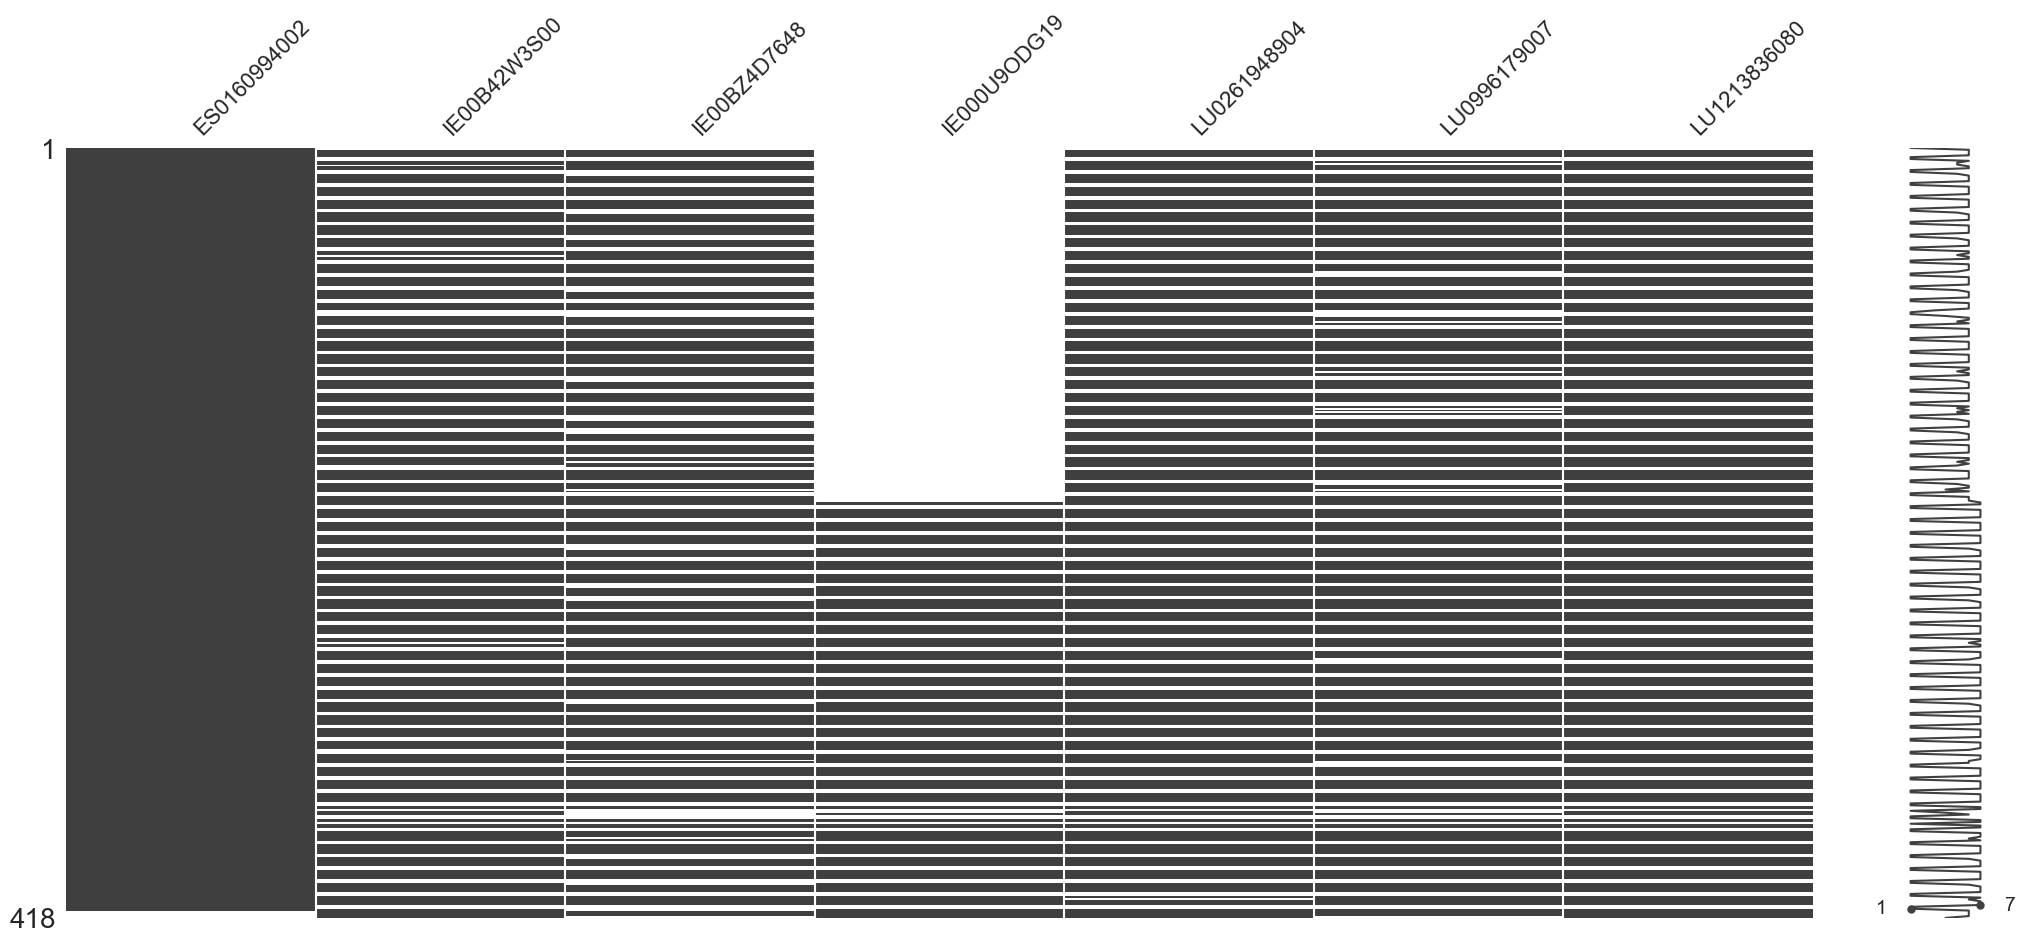

In [148]:
import missingno as mso

mso.matrix(data)

Limpieza de NA

In [149]:
data = data.dropna(axis=0, how="any")
data

,ES0160994002,IE00B42W3S00,IE00BZ4D7648,IE000U9ODG19,LU0261948904,LU0996179007,LU1213836080
Date,,,,,,,
2024-07-11,10.44,331.399,29.02,5.09,23.62,441.95,49.68
2024-07-12,10.44,333.629,28.90,5.08,23.86,443.81,49.96
2024-07-15,10.45,335.296,28.93,5.09,23.59,444.89,50.02
2024-07-16,10.45,342.410,28.88,5.16,23.69,449.34,50.29
2024-07-17,10.45,339.174,27.56,5.13,23.58,441.27,49.53
...,...,...,...,...,...,...,...
2025-02-07,10.69,370.921,30.57,6.12,25.45,489.20,54.09
2025-02-10,10.69,372.784,30.85,6.12,25.57,493.12,54.84
2025-02-12,10.69,366.855,30.53,6.13,25.74,489.99,54.46


Visualización de datos

<Axes: >

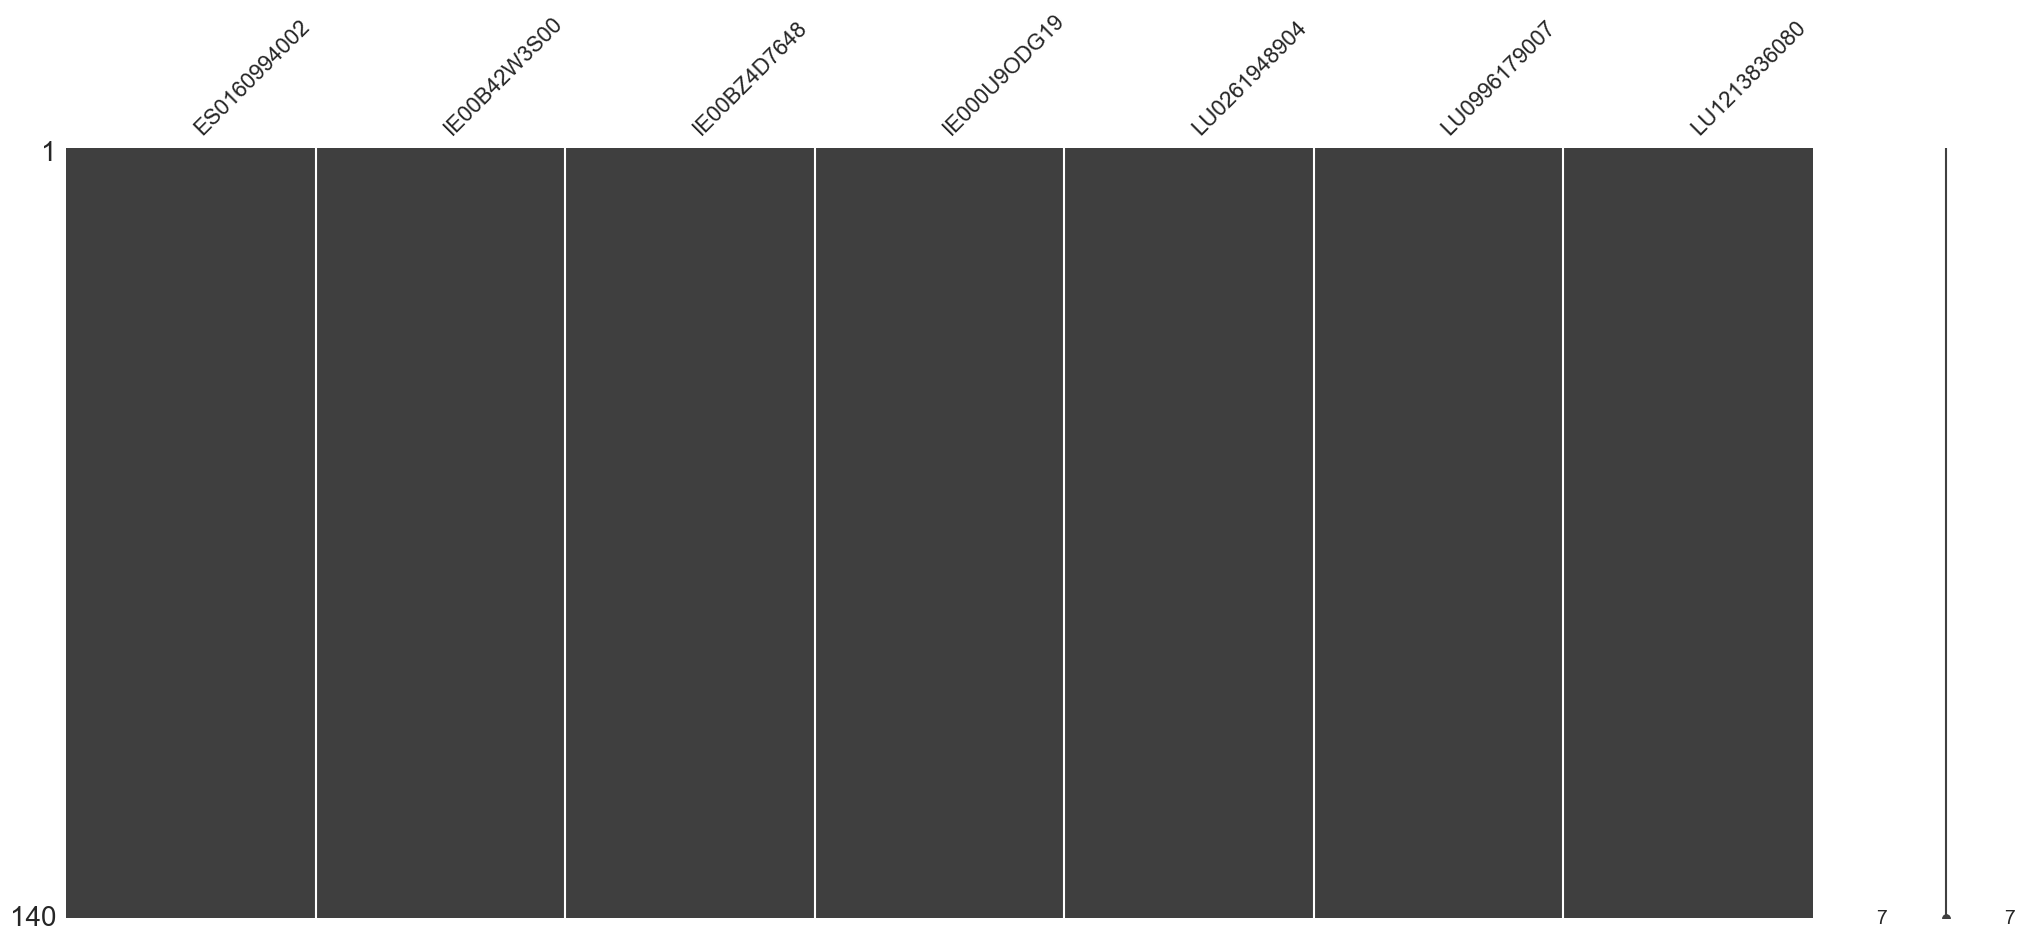

In [150]:
mso.matrix(data)

### Visualización de precios y rentabilidades

Para comparar visualmente todas las series de precios, es útil que empiecen desde el mismo valor, para ello, dividimos los precios actuales con los del instante de tiempo inicial `data.iloc[0]`.

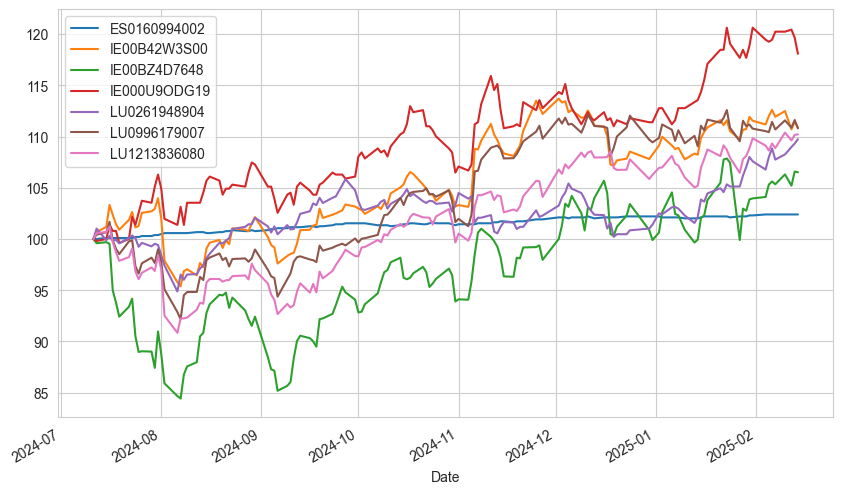

In [151]:
(data / data.iloc[0] * 100).plot(figsize=(10, 6))
plt.show()

Como siempre, vamos a calcular las rentabilidades logarítmicas y posteriormente representar sus histogramas.

* **Kurtosis**
    * Positive kurtosis means a more peaked distribution, while negative kurtosis means a flatter one.
    * A kurtosis greater than +2 suggests a too peaked distribution, while less than -2 indicates a too flat one.
* **Skewness**: Skewness measures the symmetry of a variable's distribution.
    * Negative skewness indicates more larger values, while positive skewness indicates more smaller values.
    
When skewness and kurtosis are close to zero, it's considered a normal distribution

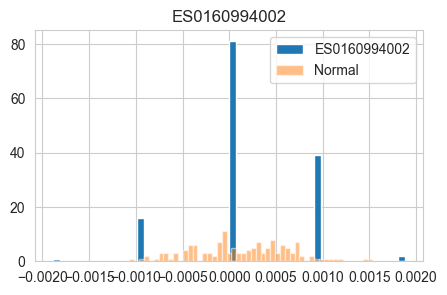

Mean = 0.0002
Std = 0.0006
Skewness = -0.0868
Kurtosis = 0.3603


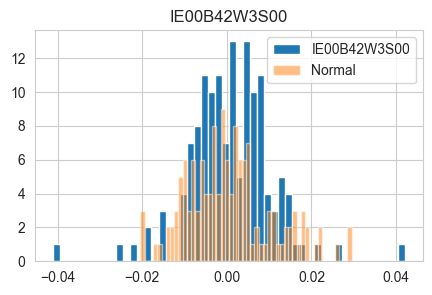

Mean = 0.0007
Std = 0.0099
Skewness = -0.1028
Kurtosis = 3.7798


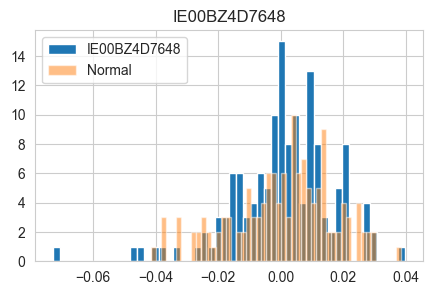

Mean = 0.0005
Std = 0.0164
Skewness = -0.9683
Kurtosis = 2.7947


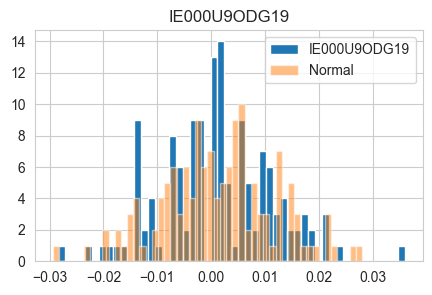

Mean = 0.0012
Std = 0.0103
Skewness = 0.1028
Kurtosis = 0.4504


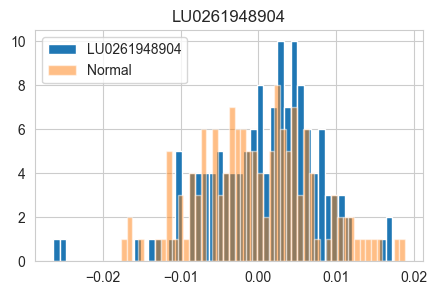

Mean = 0.0007
Std = 0.0071
Skewness = -0.7260
Kurtosis = 1.5367


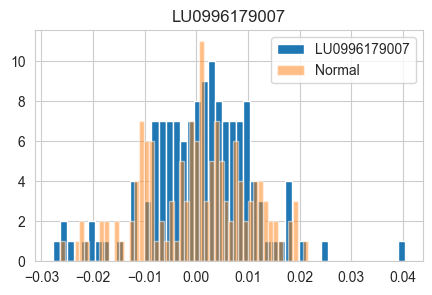

Mean = 0.0007
Std = 0.0102
Skewness = -0.0488
Kurtosis = 1.7009


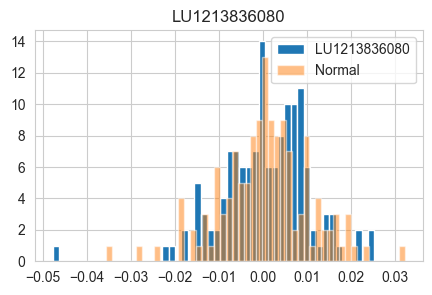

Mean = 0.0007
Std = 0.0100
Skewness = -0.8027
Kurtosis = 3.4177


In [152]:
rng = np.random.default_rng(42)

for activo in activos:
    # Retornos del activo.
    rets = np.log(data.loc[:, activo]).diff().dropna()
    # Distribución normal con la misma media y desviación estándar que el activo.
    data_normal = rng.normal(size=len(rets), loc=rets.mean(), scale=rets.std())
    df = pd.DataFrame({activo: rets.values, "Normal": data_normal})
    # Figura comparativa.
    plt.figure(figsize=(5, 3))
    plt.hist(df[activo], bins=50, alpha=1.0, label=activo)
    plt.hist(df["Normal"], bins=50, alpha=0.5, label="Normal")
    plt.legend()
    plt.title(activo)
    plt.show()
    # Estadísticos.
    print(f"Mean = {rets.mean():.4f}")
    print(f"Std = {rets.std():.4f}")
    print(f"Skewness = {rets.skew():.4f}")
    print(f"Kurtosis = {rets.kurtosis():.4f}")

Correlación

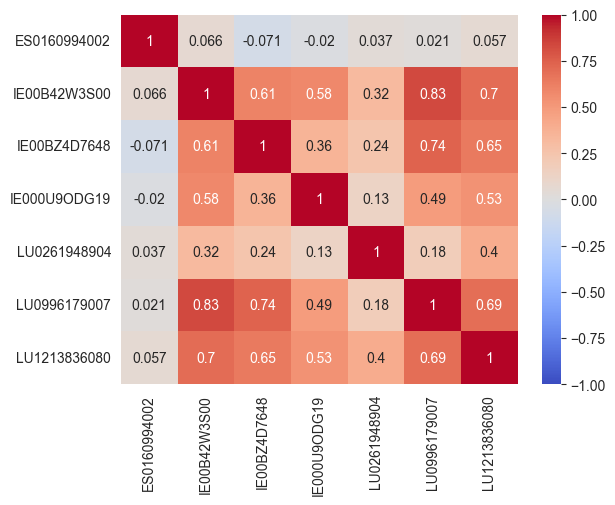

In [153]:
rets = np.log(data).diff().dropna()
sns.heatmap(rets.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

### Ejercicio

A partir de los datos descargados de los cuatro activos, genera 300.000 carteras aleatorias y represéntalas.

In [154]:
# Generamos pesos aleatorios.
num_carteras = 300000
num_activos = len(activos)

rng = np.random.default_rng(42)
pesos = rng.random(size=(num_carteras, num_activos))
pesos = pesos / np.sum(pesos, axis=1, keepdims=True)

pesos.shape

(300000, 7)

In [155]:
# Calculamos rentabilidades de los activos.
rets = np.log(data).diff().dropna()
rets.shape

(139, 7)

In [156]:
# Calculamos los retornos de las carteras utilizando multiplicación matricial.
retornos_diarios_carteras = rets @ pesos.T  # (139, 7) @ (7, 300000) = (139, 300000)

retornos_diarios_carteras.shape

(139, 300000)

In [157]:
# Calculamos el retorno esperado de cada cartera.
retornos_mean_carteras = retornos_diarios_carteras.mean(axis=0)

retornos_mean_carteras.shape

(300000,)

In [158]:
# Calculamos el riesgo de cada cartera.
std_carteras = retornos_diarios_carteras.std(axis=0)

std_carteras.shape

(300000,)

In [159]:
# Cartera del cliente.
cartera_cliente = {
    "ES0160994002": 0.20,
    "IE00B42W3S00": 0.10,
    "IE00BZ4D7648": 0.30,
    "IE000U9ODG19": 0.02,
    "LU0261948904": 0.18,
    "LU0996179007": 0.18,
    "LU1213836080": 0.02,
}
# Rentabilidad esperada de la cartera del cliente.
ret_cliente = rets @ np.array(list(cartera_cliente.values()))
# Riesgo de la cartera del cliente.
std_cliente = ret_cliente.std()

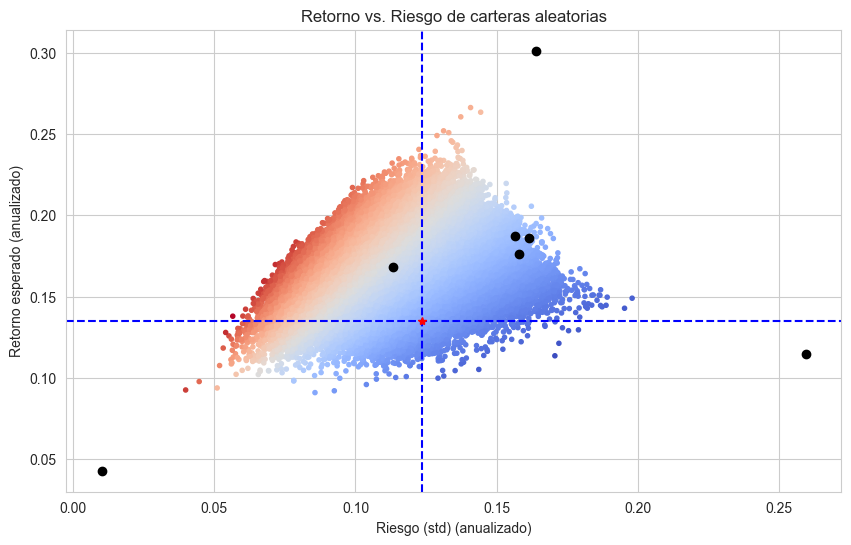

In [164]:
# Graficamos rentabilidad vs. riesgo.
plt.figure(figsize=(10, 6))
plt.scatter(
    x=std_carteras * np.sqrt(252),
    y=retornos_mean_carteras * 252,
    c=retornos_mean_carteras / std_carteras,
    marker=".",
    cmap="coolwarm",
)
# Graficamos los activos individuales.
for asset_name in rets.columns:
    asset_ret = rets[asset_name].mean()
    aset_std = rets[asset_name].std()

    plt.plot(aset_std * np.sqrt(252), asset_ret * 252, marker="o", color="black")
# Graficamos la cartera del cliente.

plt.axvline(std_cliente * np.sqrt(252), color="blue", linestyle="--")
plt.axhline(ret_cliente.mean() * 252, color="blue", linestyle="--")
plt.plot(std_cliente * np.sqrt(252), ret_cliente.mean() * 252, marker="*", color="red")

plt.xlabel("Riesgo (std) (anualizado)")
plt.ylabel("Retorno esperado (anualizado)")
plt.title("Retorno vs. Riesgo de carteras aleatorias")
plt.show()